# Using THREDDS/Opendap to subset CCI Sea State L4 dataset

A **THREDDS Data Server** (TDS, https://www.unidata.ucar.edu/software/tds) provides catalog, metadata, and data access services for scientific data. Every TDS publishes THREDDS catalogs that advertise the datasets and services it makes available. The available remote data access protocols include OPeNDAP, OGC WCS, OGC WMS, and HTTP.

The TDS also supports several dataset collection services including some sophisticated dataset aggregation capabilities. This allows the TDS to aggregate a collection of datasets into a single virtual dataset, greatly simplifying user access to that data collection.

In CCI Sea State, we provide access through a THREDDS server to the Altimeter L4 dataset (gridded monthly statistics of SWH). All monthly files are nicely aggregated by THREDDS into a 3-dimensional data array (time, lat, lon) that can be remotely subsetted and read through **OpenDAP** API.

The end-point to read remotely the CCI Sea State L4 dataset is: https://tds0.ifremer.fr/thredds/dodsC/ESACCI-SEASTATE-L4-SWH-MULTI_1M

In this tutorial, we give you an example on how to use it from python (but libraries are available in other languages for OpenDAP).

Let's first import `xarray`, this is the only package you need to read remotely data through OPENDAP:

In [1]:
import xarray as xr

Open the OpenDAP end-point as you would open a file on local storage. We see the result as a 3-dimensional Dataset object:

In [2]:
ds = xr.open_dataset('https://tds0.ifremer.fr/thredds/dodsC/ESACCI-SEASTATE-L4-SWH-MULTI_1M')
ds

<xarray.Dataset> Size: 3GB
Dimensions:                       (lat: 160, nv: 2, lon: 360, time: 385)
Coordinates:
  * lat                           (lat) float32 640B -79.5 -78.5 ... 78.5 79.5
  * lon                           (lon) float32 1kB -179.5 -178.5 ... 179.5
  * time                          (time) |S64 25kB b'1992-01-01T00:00:00Z' .....
Dimensions without coordinates: nv
Data variables: (12/23)
    crs                           int32 4B ...
    lat_bnds                      (lat, nv) float64 3kB ...
    lon_bnds                      (lon, nv) float64 6kB ...
    time_bnds                     (nv) datetime64[ns] 16B ...
    swh_mean                      (time, lat, lon) float64 177MB ...
    swh_rms                       (time, lat, lon) float64 177MB ...
    ...                            ...
    swh_count_greater_than_3.50   (time, lat, lon) float64 177MB ...
    swh_count_greater_than_4.00   (time, lat, lon) float64 177MB ...
    swh_count_greater_than_5.00   (time, lat, lon) float64 177MB ...
    swh_count_greater_than_6.00   (time, lat, lon) float64 177MB ...
    swh_count_greater_than_8.00   (time, lat, lon) float64 177MB ...
    swh_count_greater_than_10.00  (time, lat, lon) float64 177MB ...
Attributes: (12/61)
    Conventions:                   CF-1.7, ACDD-1.3, ISO 8601
    title:                         ESA CCI Sea State L4
    id:                            ESACCI-SEASTATE-L4-SWH
    institution:                   Institut Francais de Recherche pour l'Expl...
    institution_abbreviation:      Ifremer/Cersat, ESA
    source:                        CCI Sea State L4 Processor
    ...                            ...
    time_coverage_end:             2024-01-01T00:00:00Z
    uuid:                          0e51c5e1-25f4-4e27-b279-5e3dc689aa09
    Metadata_Conventions:          Climate and Forecast (CF) 1.7, Attribute C...
    processing_software:           Cersat/Cerbere 1.0
    geospatial_vertical_units:     meters above mean sea level
    geospatial_vertical_positive:  up

THREDDS convert datetime information to strings.We can convert them back to numpy `datetime64` data type:

In [3]:
import numpy as np
ds['time'] = ds['time'].astype(np.datetime64)

/home/jfpiolle/mambaforge/envs/cciseastate/lib/python3.10/site-packages/xarray/core/duck_array_ops.py:226: UserWarning: no explicit representation of timezones available for np.datetime64
  return data.astype(dtype, **kwargs)
/tmp/ipykernel_12784/2712952193.py:2: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  ds['time'] = ds['time'].astype(np.datetime64)


Let's now read a full time series of the mean significant wave height (`swh_mean` variable) at a given point (longitude=-4.5, latitude=46.5). Note that you must provide latitude and longitude that exist in the dataset coordinates (it won't approximate to the closest grid point but raise an error instead).

This is a lazy operation so `compute()` must be executed to actully donwload the data.

In [4]:
%%time
swh = ds.sel(lon=-4.5, lat=46.5).swh_mean.compute()
swh

CPU times: user 7.45 ms, sys: 178 μs, total: 7.63 ms
Wall time: 1.6 s


<xarray.DataArray 'swh_mean' (time: 385)> Size: 3kB
array([       nan,        nan,        nan, 4.00450426, 1.62691911,
       1.24697002, 1.3029859 , 1.50505987, 2.18745876, 2.34864877,
       3.2429453 , 2.70808264, 3.2269475 , 1.7091934 , 2.27961412,
       1.70520235, 1.5360816 , 1.74151158, 1.21884926, 1.42713626,
       1.64242598, 2.04116045, 2.84221559, 3.9666163 , 4.01187164,
       3.28822174, 2.52787344, 2.77239112, 2.00729516, 1.60391777,
       1.10071689, 1.34837175, 1.72866878, 2.27606631, 2.30940734,
       3.03387914, 3.80585203, 3.40922392, 3.25843354, 1.96121485,
       1.86991446, 1.39997749, 1.27701873, 1.25161052, 2.35178804,
       2.13346882, 2.55027794, 2.68054916, 3.4820124 , 2.59531694,
       1.66874813, 1.37940835, 1.57848261, 1.80074884, 1.33871966,
       1.20363036, 1.73856507, 2.98850127, 3.15688764, 1.73939929,
       2.04401594, 4.12882286, 2.15799582, 1.21848055, 1.94160772,
       1.7497309 , 0.93379005, 1.52699131, 1.18560366, 1.7167616 ,
       3.86040353, 3.02544485, 5.87604816, 2.36852326, 2.23780139,
       2.90962846, 1.36346188, 1.69388749, 1.2581888 , 1.05794619,
       2.47796821, 2.73849594, 2.6274398 , 3.21895235, 3.60331313,
       2.9014477 , 1.89698654, 2.23708634, 1.62149218, 1.77085799,
       1.1437007 , 0.82534729, 2.26334428, 2.46453583, 2.31015149,
       2.76807197, 2.53901978, 3.54513545, 1.70660192, 2.25389407,
...
       1.90443473, 3.19246921, 3.76968188, 4.10989197, 3.34623366,
       3.24178148, 1.88427015, 1.30877978, 1.60106146, 1.29961134,
       1.67250635, 1.83547264, 1.86065132, 2.25850796, 2.97591842,
       1.58013757, 3.08947928, 3.09359741, 1.1529683 , 1.42852911,
       1.99433253, 1.46497282, 1.24758751, 2.34346398, 2.31391591,
       2.30283605, 3.30655726, 3.90634757, 3.37303667, 3.35758164,
       2.62189812, 1.43600052, 1.27824349, 1.35431232, 0.93619615,
       1.31802339, 2.46810752, 3.29364591, 3.92897153, 3.12446053,
       3.00341383, 2.54351677, 2.39996573, 1.96422478, 1.05279995,
       1.17435423, 1.07161592, 2.82019531, 2.53626033, 3.84303466,
       2.03860543, 3.34978516, 4.17224908, 3.84301884, 1.46344154,
       0.99613456, 1.03533343, 1.57199356, 0.90201581, 0.89629134,
       3.49006741, 2.12503559, 2.94891507, 1.82977975, 4.13881985,
       2.63710605, 1.43094772, 2.49416234, 1.39797937, 1.21968721,
       1.06979261, 1.44802638, 2.36858676, 2.02747083, 3.61933511,
       2.45399883, 3.4845588 , 2.44099592, 2.02804653, 1.469723  ,
       1.63536963, 1.1023473 , 1.34039651, 1.50924365, 2.33420492,
       4.30596076, 2.723619  , 3.12852402, 2.19517799, 3.79751674,
       2.28613093, 1.43639394, 1.03385503, 1.38734283, 1.50247639,
       1.77777736, 2.64260491, 2.83453299, 3.91160095, 5.23718649])
Coordinates:
    lat      float32 4B 46.5
    lon      float32 4B -4.5
  * time     (time) datetime64[ns] 3kB 1992-01-01 1992-02-01 ... 2024-01-01
Attributes:
    long_name:              mean of median significant wave height values
    coverage_content_type:  physicalMeasurement
    source:                 swh_denoised
    grid_mapping:           crs
    cell_method:            lat: lon: median (interval: 0.1 degree_N interval...
    units:                  m
    _ChunkSizes:            [  1 160 360]

We can now display the returned time series:

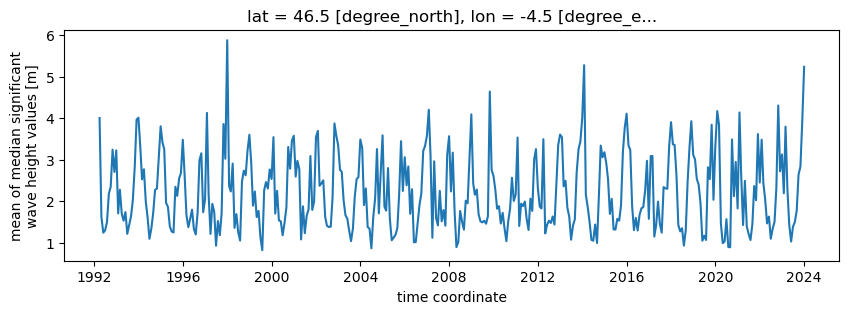

In [5]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10,3))
swh.plot()

To read a subset over an area instead of at a single point, just use slices in the selection call:

In [6]:
%%time
swh_area = ds.sel(lon=slice(-6.5, -3.5), lat=slice(44.5, 48.5)).swh_mean.compute()
swh_area.shape

CPU times: user 11 ms, sys: 310 μs, total: 11.3 ms
Wall time: 3.28 s


(385, 5, 4)

We can no display a time series of the mean value of `swh_mean` over the selected area (`swh.mean(dim=['lon','lat'])`):

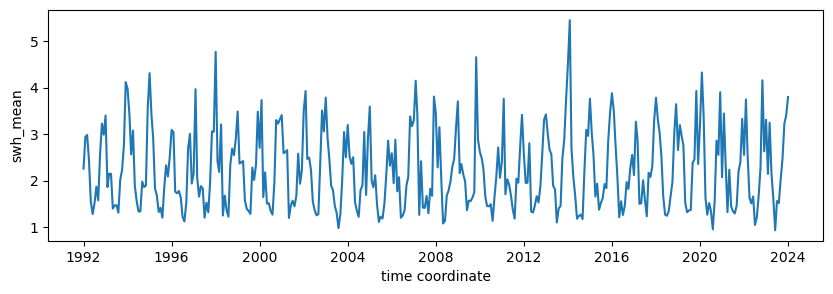

In [8]:
fig = plt.figure(figsize=(10,3))

swh_area.mean(dim=['lon','lat']).plot()